### Question 3

##### (a)

In [51]:

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# set seed
rng = np.random.default_rng(seed=39)

In [52]:


# generate noise
e_m = rng.normal(loc=0, scale=np.sqrt(2), size=1500)
e_x = rng.normal(loc=0, scale=1, size=1500)
e_y = rng.normal(loc=0, scale=1, size=1500)

# generate observations
A = rng.binomial(n=1, p=0.4, size=1500)
M = 1.5 * A + e_m
X = 2 * M + 0.5 * A + e_x
Y = 4 * X + M + e_y

# create dataframe
columns = ['A', 'M', 'X', 'Y']
data = np.column_stack((A, M, X, Y))
df = pd.DataFrame(data, columns=columns)
df['A'] = df['A'].astype(int)

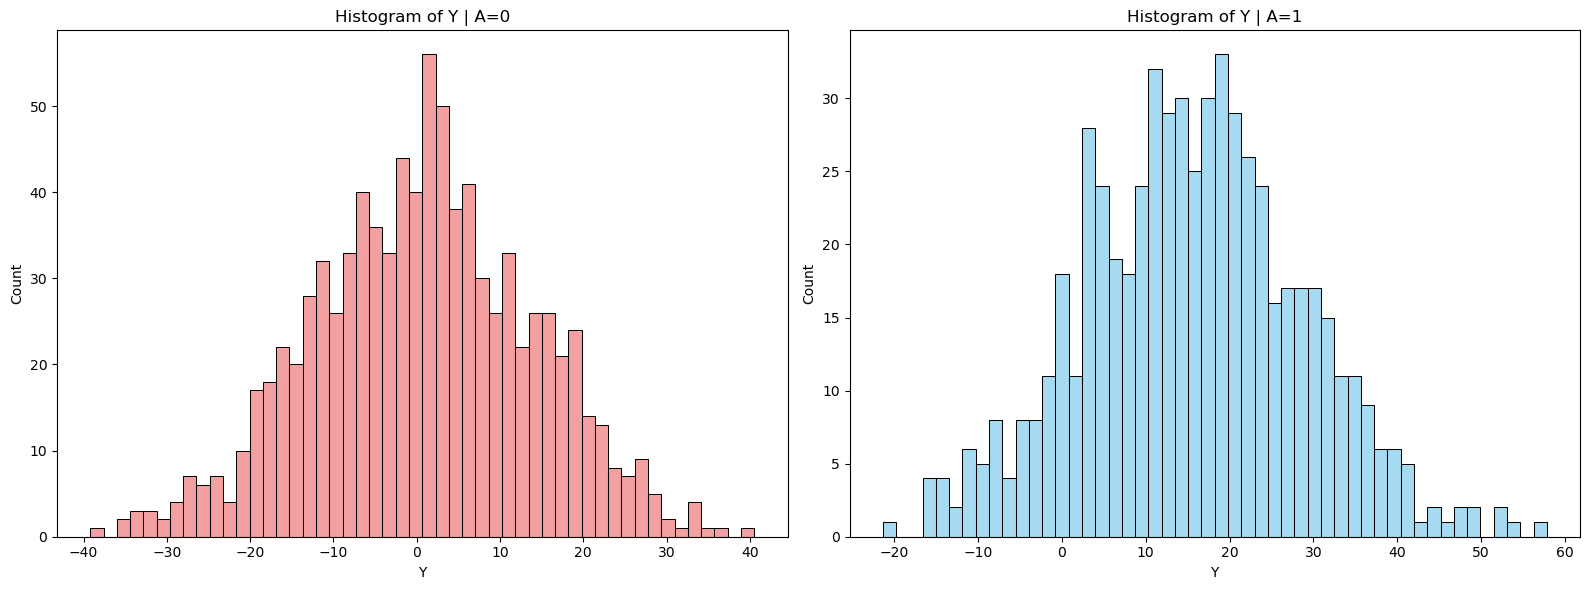

In [53]:
# plot data
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_A1 = df[df['A'] == 1]
df_A0 = df[df['A'] == 0]
sns.histplot(data=df_A1, x='Y', bins=50, kde=False, color='skyblue', ax=axes[1])
sns.histplot(data=df_A0, x='Y', bins=50, kde=False, color='lightcoral', ax=axes[0])
axes[0].set_title('Histogram of Y | A=0')
axes[1].set_title('Histogram of Y | A=1')

plt.tight_layout()
plt.savefig("Y_hist_low_var.png")
plt.show()

 

##### (b)

In [54]:
# compute covariance
cov_A_Y = np.cov(df['A'], df['Y'])[0, 1]
print(f"Covariance between A and Y: {cov_A_Y}")

Covariance between A and Y: 3.580650741266434


##### (c)

In [55]:
from sklearn.linear_model import LinearRegression

# run regression 1
Xs = df[['A']]
ys = df['Y']

model = LinearRegression()
model.fit(Xs, ys)
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)



Intercept: 0.6688130653971598
Coefficients: [14.8848718]


In [56]:
# run regression 2
Xs = df[['A', 'X']]

model = LinearRegression()
model.fit(Xs, ys)
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)


Intercept: -0.024084450257761958
Coefficients: [-0.04123016  4.44795859]


##### (d)

In [57]:
# simulate data with higher varaince
# generate noise
e_m = rng.normal(loc=0, scale=np.sqrt(8), size=1500)
e_x = rng.normal(loc=0, scale=np.sqrt(8), size=1500)
e_y = rng.normal(loc=0, scale=np.sqrt(8), size=1500)

# generate observations
A = rng.binomial(n=1, p=0.4, size=1500)
M = 1.5 * A + e_m
X = 2 * M + 0.5 * A + e_x
Y = 4 * X + M + e_y

# create dataframe
columns = ['A', 'M', 'X', 'Y']
data2 = np.column_stack((A, M, X, Y))
df2 = pd.DataFrame(data2, columns=columns)
df2['A'] = df2['A'].astype(int)

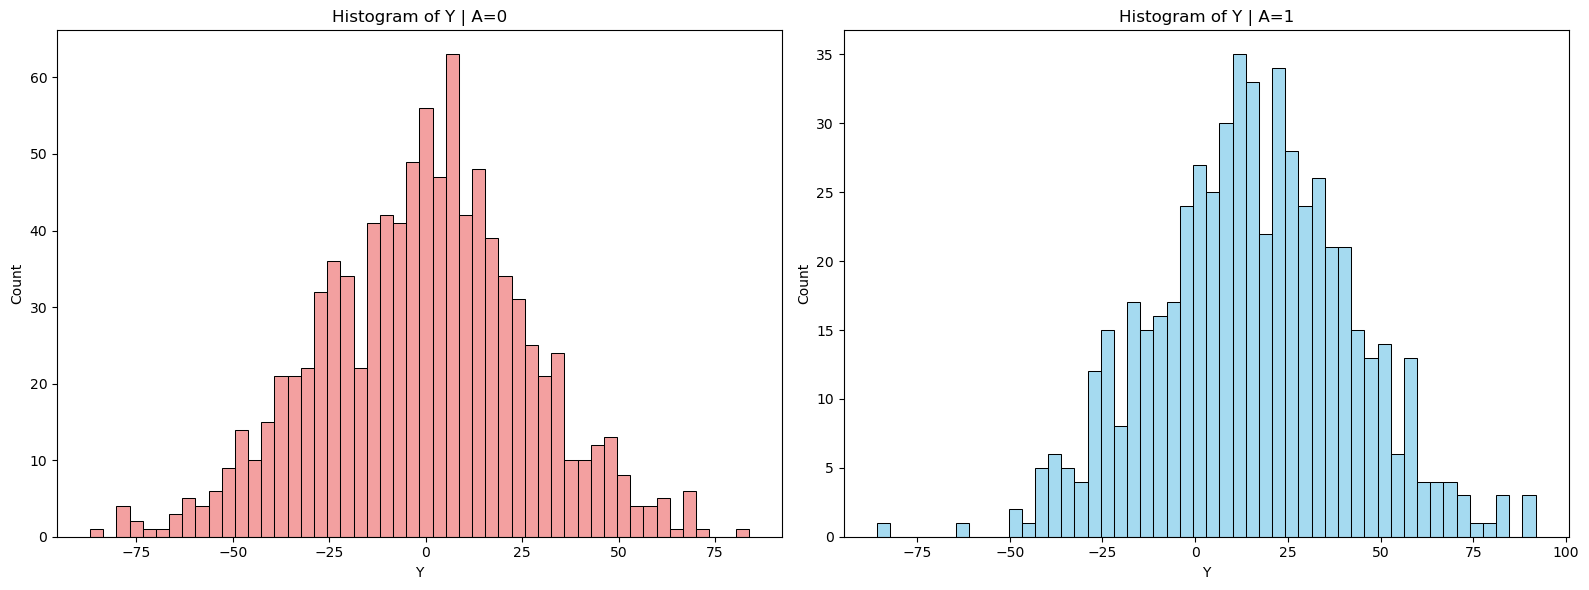

In [58]:
# plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df2_A1 = df2[df2['A'] == 1]
df2_A0 = df2[df2['A'] == 0]
sns.histplot(data=df2_A1, x='Y', bins=50, kde=False, color='skyblue', ax=axes[1])
sns.histplot(data=df2_A0, x='Y', bins=50, kde=False, color='lightcoral', ax=axes[0])
axes[0].set_title('Histogram of Y | A=0')
axes[1].set_title('Histogram of Y | A=1')


plt.tight_layout()
plt.savefig("Y_hist_high_var.png")
plt.show()

In [59]:
# compute covariance
cov_A_Y = np.cov(df2['A'], df2['Y'])[0, 1]
print(f"Covariance between A and Y: {cov_A_Y}")

Covariance between A and Y: 3.722072717085875


In [60]:

# run regression 1
Xs = df2[['A']]
ys = df2['Y']

model = LinearRegression()
model.fit(Xs, ys)
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -0.6761977734701183
Coefficients: [15.91022473]


In [61]:
# run regression 2
Xs = df[['A', 'X']]

model = LinearRegression()
model.fit(Xs, ys)
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 5.652752165988075
Coefficients: [-1.53565618  0.14460223]
